# Computing Exercise 4: GAIA Sky Spying

In [2]:
# LIBRARIES!
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn import metrics
from tabulate import tabulate
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

plt.rcParams.update({'font.size': 15,
                     'axes.titlesize': 17,
                     'axes.labelsize': 15,
                     'xtick.labelsize': 13,
                     'ytick.labelsize': 13,
                     'legend.fontsize': 15,
                     'font.family': 'Garamond'})

# The copy_on_write attribute is set to true to allow the code in part 3 to avoid a SettingWithCopyWarning error
pd.options.mode.copy_on_write = True

# Part 1

In [4]:
unfiltered_df = pd.read_csv('m45-clean.csv', on_bad_lines = 'skip', na_values = [' ', '  ', '   ']).dropna()
unfiltered_df

,ra,dec,l,b,parallax,pmra,pmdec,g,bp,rp,parallax_error,ruwe
0,57.625696,22.641349,168.310840,-24.057028,0.600933,-1.265193,-3.664396,17.942938,18.714838,17.003864,0.188517,0.969284
1,57.649262,22.653573,168.318970,-24.033209,0.321754,0.175684,-0.299412,19.470880,19.976950,18.786230,0.384609,1.031118
2,57.656456,22.651088,168.326124,-24.030459,0.707862,0.710553,-3.771763,20.349250,20.951847,19.351307,0.825918,1.067443
4,57.509144,22.587982,168.265176,-24.169662,0.034489,1.556730,-9.341153,19.528042,20.527487,18.462700,0.473237,1.053412
7,57.542429,22.609191,168.273754,-24.133154,0.523849,-1.368385,-2.209889,20.212969,20.604141,19.617247,0.803734,1.023322
...,...,...,...,...,...,...,...,...,...,...,...,...
113624,58.632625,25.083008,167.219537,-21.649043,0.196881,-0.906686,-2.048582,19.084265,19.617480,18.421478,0.274504,0.956039
113625,58.649319,25.085687,167.229391,-21.636719,0.648660,2.535123,-8.754439,14.488680,14.932409,13.871096,0.023363,1.020822
113626,58.657607,25.097503,167.226540,-21.622974,0.127725,-1.448554,-2.715169,19.855272,20.465996,19.079899,0.492113,0.939422
113627,58.648412,25.094536,167.222216,-21.630847,0.131356,0.668039,0.138146,17.115145,17.436308,16.637964,0.082166,1.036696


In [5]:
ra = unfiltered_df['ra']
dec = unfiltered_df['dec']
l = unfiltered_df['l']
b = unfiltered_df['b']
parallax = unfiltered_df['parallax']
pmra = unfiltered_df['pmra']
pmdec = unfiltered_df['pmdec']
g = unfiltered_df['g']
bp = unfiltered_df['bp']
rp = unfiltered_df['rp']
parallax_error = unfiltered_df['parallax_error']
ruwe = unfiltered_df['ruwe']

The number of datapoints before filtering: 97606 


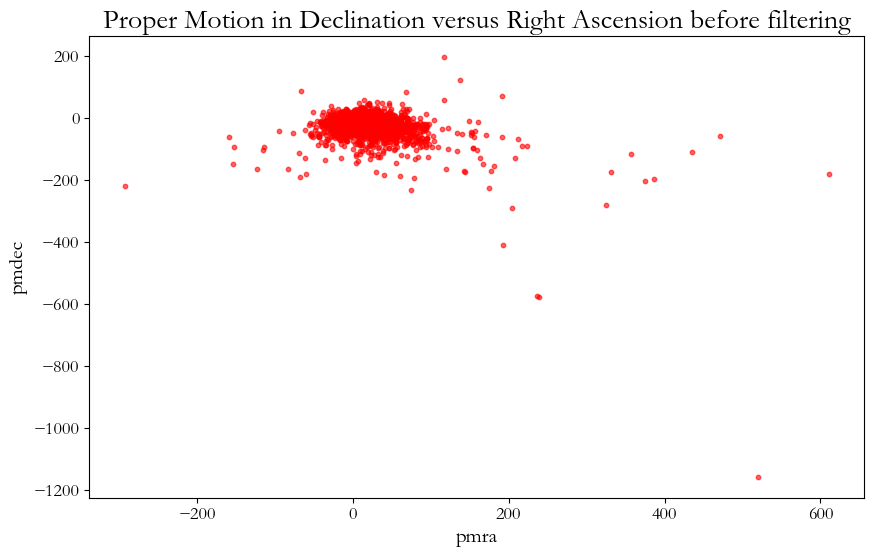

In [6]:
plt.figure(figsize = (10,6))
    
# Plot a scatter
plt.scatter(unfiltered_df['pmra'], unfiltered_df['pmdec'], s=10, c='r', alpha=0.6)
    
# Set the appropriate axis labels
plt.xlabel('pmra')
plt.ylabel('pmdec')

# Set the title of the plot
plt.title('Proper Motion in Declination versus Right Ascension before filtering', fontsize=20)
print(f'The number of datapoints before filtering: {len(unfiltered_df)} ');

# Clearly there is a main core of data points with a few outliers, as required.

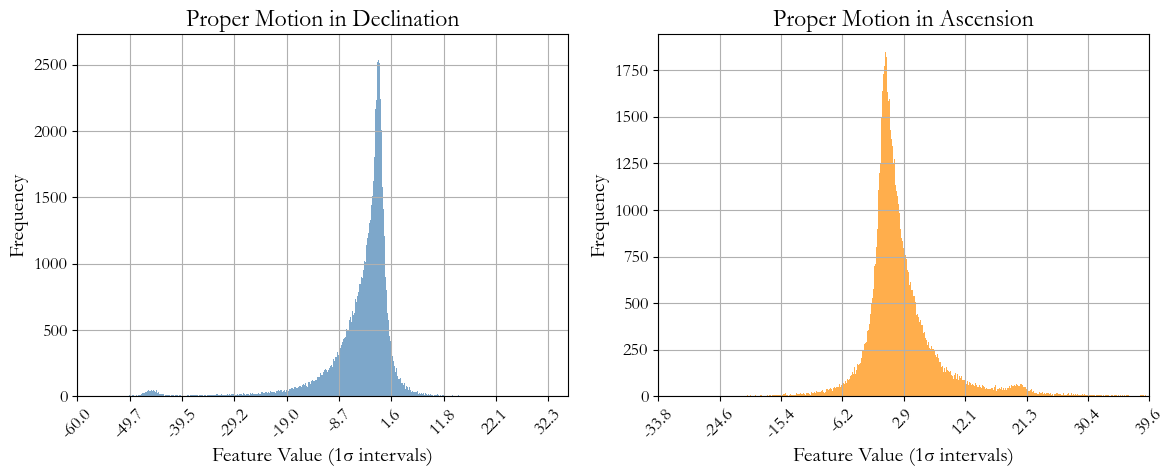

In [8]:
# Calculate mean and standard deviation for both features
mean_declination = unfiltered_df['pmdec'].mean()
std_declination = unfiltered_df['pmdec'].std()

mean_ascension = unfiltered_df['pmra'].mean()
std_ascension = unfiltered_df['pmra'].std()

# Define the number of bins
bins = 700

# Calculate bin edges for declination
# Extend the lower bound to -60
declination_range_lower = -60
declination_range_upper = mean_declination + 4 * std_declination
declination_bin_edges = np.linspace(declination_range_lower, 
                                    declination_range_upper, 
                                    bins + 1)

# Calculate bin edges for ascension
ascension_range = 4 * std_ascension
ascension_bin_edges = np.linspace(mean_ascension - ascension_range, 
                                  mean_ascension + ascension_range, 
                                  bins + 1)

# Plot for proper motion in declination
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(unfiltered_df['pmdec'], bins=declination_bin_edges, alpha=0.7, color='steelblue')
plt.xticks(np.arange(declination_range_lower, 
                     declination_range_upper + 1, 
                     std_declination), 
           labels=[f'{v:.1f}' for v in np.arange(declination_range_lower, 
                                                declination_range_upper + 1, 
                                                std_declination)], 
           rotation=45)
plt.xlim(declination_bin_edges[0], declination_bin_edges[-1])
plt.title('Proper Motion in Declination')
plt.xlabel('Feature Value (1σ intervals)')
plt.ylabel('Frequency')
plt.grid(True)

# Plot for proper motion in ascension
plt.subplot(1, 2, 2)
plt.hist(unfiltered_df['pmra'], bins=ascension_bin_edges, alpha=0.7, color='darkorange')
plt.xticks(np.arange(mean_ascension - 4 * std_ascension, 
                     mean_ascension + 4 * std_ascension + 1, 
                     std_ascension), 
           labels=[f'{v:.1f}' for v in np.arange(mean_ascension - 4 * std_ascension, 
                                                mean_ascension + 4 * std_ascension + 1, 
                                                std_ascension)], 
           rotation=45)
plt.xlim(ascension_bin_edges[0], ascension_bin_edges[-1])
plt.title('Proper Motion in Ascension')
plt.xlabel('Feature Value (1σ intervals)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

### Here a new column is added to the data frame to hold values for relative parallax error, as filtering is done using this rather than absolute parallax error

In [10]:
# Adding a new column to be the relative parallax error in percentage form
unfiltered_df['relative_parallax_error'] = unfiltered_df['parallax_error']/unfiltered_df['parallax'] * 100

# Filtering the data for the section we're interested in
df = unfiltered_df.query('parallax >= 0 & relative_parallax_error <= 20 & -60 <= pmdec <= 15 & -14 <= pmra <= 26')

### Reassigning feature names to plot the filtered data

In [12]:
ra = df['ra']
dec = df['dec']
l = df['l']
b = df['b']
parallax = df['parallax']
pmra = df['pmra']
pmdec = df['pmdec']
g = df['g']
bp = df['bp']
rp = df['rp']
parallax_error = df['parallax_error']
ruwe = df['ruwe']

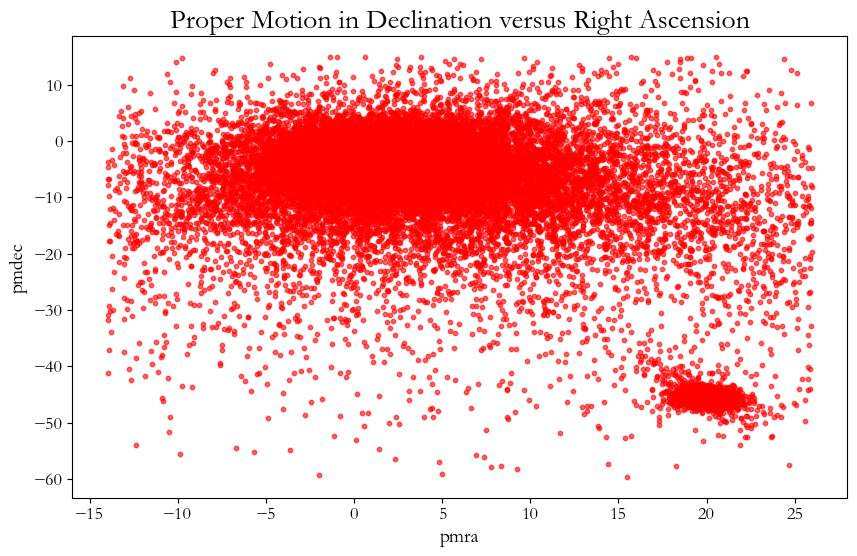

The number of datapoints remaining after filtering: 25300 


In [13]:
# Set figure size
plt.figure(figsize = (10,6))
    
# Plot a scatter graph
plt.scatter(pmra, pmdec, s=10, c='r', alpha=0.6)
    
# Set the appropriate axis labels
plt.xlabel('pmra', fontsize=14)
plt.ylabel('pmdec', fontsize=14)

# Set the plot title
plt.title('Proper Motion in Declination versus Right Ascension', fontsize=20);
plt.show()
print(f'The number of datapoints remaining after filtering: {len(df)} ')

# Part 2 - Viewing mean and standard deviation values for each feature and scaling the data

In [15]:
print(df.mean())
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print(df.std())

ra                          56.686288
dec                         24.449604
l                          166.277122
b                          -23.306837
parallax                     1.563091
pmra                         4.041285
pmdec                       -7.757551
g                           16.273475
bp                          17.035493
rp                          15.449017
parallax_error               0.098856
ruwe                         1.130673
relative_parallax_error      8.535170
dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ra                          1.097783
dec                         0.991934
l                           1.092871
b                           0.987730
parallax                    1.585925
pmra                        7.160520
pmdec                      11.005215
g                           1.921847
bp                          2.196929
rp                          1.776955
parallax_error              0.102433
ruwe                        0.796668
relative_

## Practice for scaling the data, to be re-done in part 4

In [17]:
# Initialise StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# Verify results
print('Means:\n', scaled_df.mean())
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print('Standard Deviations:\n', scaled_df.std())

Means:
 ra                         6.466220e-15
dec                       -1.163830e-15
l                          2.022997e-14
b                         -2.884860e-15
parallax                   3.089316e-17
pmra                      -3.033147e-17
pmdec                     -2.836554e-17
g                         -1.436672e-15
bp                         4.587635e-16
rp                        -5.135988e-16
parallax_error            -7.007131e-17
ruwe                       5.925870e-17
relative_parallax_error    2.224308e-16
dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Standard Deviations:
 ra                         1.00002
dec                        1.00002
l                          1.00002
b                          1.00002
parallax                   1.00002
pmra                       1.00002
pmdec                      1.00002
g                          1.00002
bp                         1.00002
rp                         1.00002
parallax_error             1.00002
ruwe       

# Part 3 - Clustering techniques

Number of stars in the K-mean model's interesting cluster: 1257
Number of stars in the Gaussion Mixture model's interesting cluster: 1082


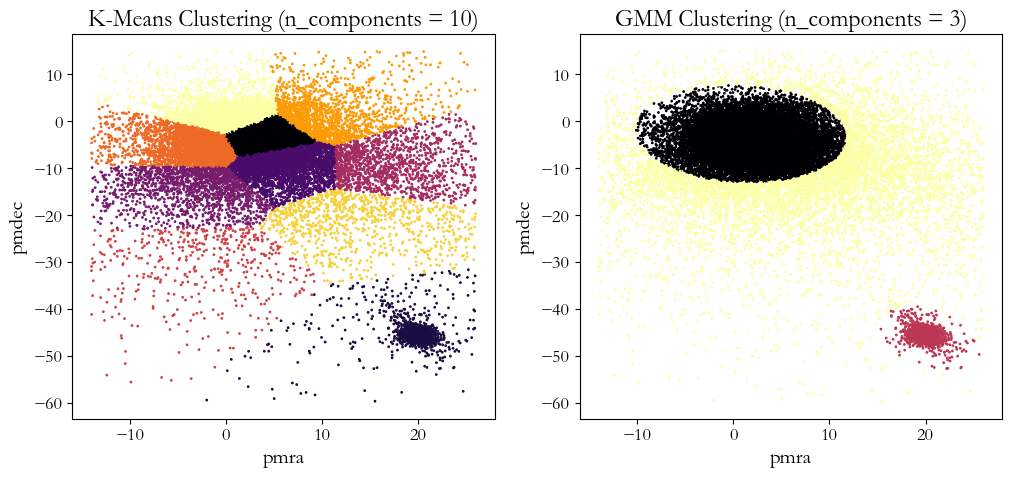

In [19]:
# Extract the relevant columns from the unscaled dataframe
cluster_data = df[['pmdec', 'pmra']]

# Set colour map for plots
colour_map = 'inferno'

# Perform K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans_fit = kmeans.fit_predict(cluster_data)

# Include a K-means column for use later, when counting how many stars are in the interesting cluster
df['kmeans_fit'] = kmeans_fit

# Perform GMM clustering
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_fit = gmm.fit_predict(cluster_data)

# Include a similar column to the above K-means for the Gaussion Mixture model
df['gmm_fit'] = gmm_fit

plt.figure(figsize=(12, 5))

# Plot K-Means results
plt.subplot(1, 2, 1)
plt.scatter(df['pmra'], df['pmdec'], c=kmeans_fit, cmap=colour_map, s=1)
plt.title('K-Means Clustering (n_components = 10)')
plt.xlabel('pmra')
plt.ylabel('pmdec')

slightly_interesting_stars = df[df['kmeans_fit'].isin([1])]

# Check the number of stars in the K-means interesting cluster
print(f"Number of stars in the K-mean model's interesting cluster: {len(slightly_interesting_stars)}")

# Plot GMM results
plt.subplot(1, 2, 2)
plt.scatter(df['pmra'], df['pmdec'], c=gmm_fit, cmap=colour_map, s=1)
plt.title('GMM Clustering (n_components = 3)')
plt.xlabel('pmra')
plt.ylabel('pmdec')

interesting_stars_with_labels = df[df['gmm_fit'].isin([1])]

# Check the number of stars in the interesting cluster
print(f"Number of stars in the Gaussion Mixture model's interesting cluster: {len(interesting_stars_with_labels)}")

plt.show()

# The last two columns, 'kmeans_fit' and 'gmm_fit',were only necessary for printing the numbers of stars in their respective interesting clusters
# Therefore they are now removed by a change of dataframe name
unscaled_interesting_stars = interesting_stars_with_labels.iloc[:, :-3]

#### As we can see, with an equal number of components for each style of clustering, the GM model narrowed the dataframe down to the required number (around 1000).

>As an extension, here is another clustering technique, Spectral Clustering, to compare with K-Means and GMM

Number of stars in the Spectral Clustering model's interesting cluster: 939


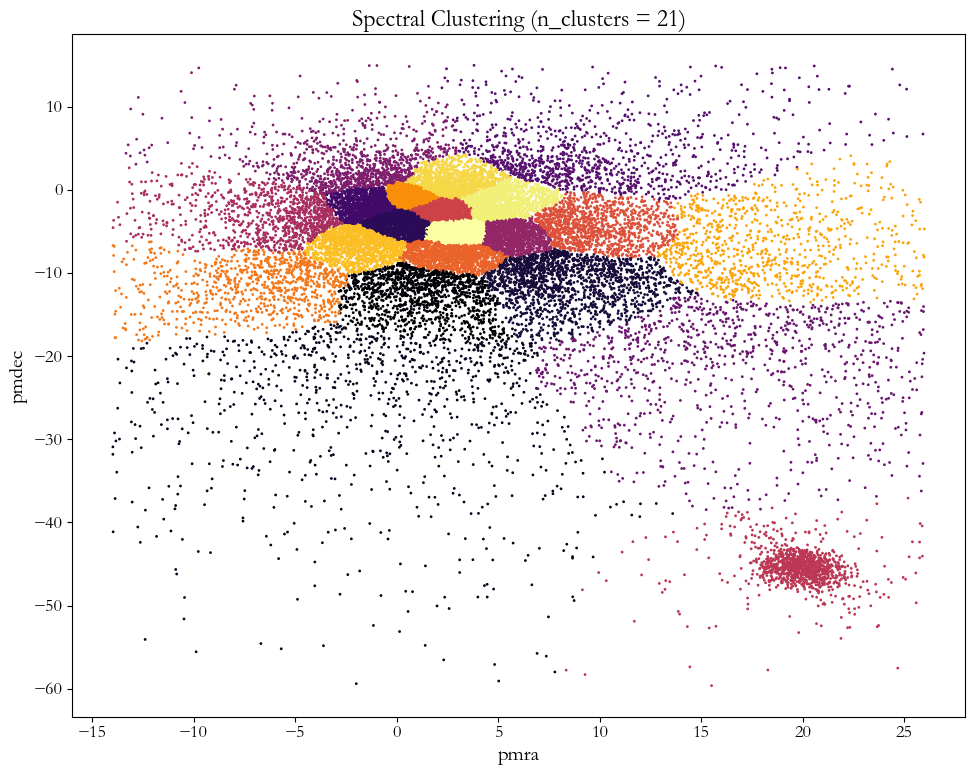

In [22]:
# Perform Spectral Clustering
spectral = SpectralClustering(n_clusters=21, affinity='nearest_neighbors', random_state=42)
spectral_fit = spectral.fit_predict(cluster_data)

# Include a spectral clustering column
df['spectral_fit'] = spectral_fit

# Plot Spectral Clustering results
plt.figure(figsize=(10, 8))
plt.scatter(df['pmra'], df['pmdec'], c=spectral_fit, cmap=colour_map, s=1)
plt.title('Spectral Clustering (n_clusters = 21)')
plt.xlabel('pmra')
plt.ylabel('pmdec')

spectral_interesting_stars = df[df['spectral_fit'].isin([1])]

# Check the number of stars in the spectral clustering interesting cluster
print(f"Number of stars in the Spectral Clustering model's interesting cluster: {len(spectral_interesting_stars)}")

plt.tight_layout()
plt.show()

# Part 4

#### Standardizing the interesting stars dataframe is done using the same method as in part 2.
##### This was re-done as the smaller dataframe including only the star we're interested in will have different variances to the original cropped and cleaned dataframe.

In [25]:
# Initialise StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_interesting_stars_data = scaler.fit_transform(unscaled_interesting_stars)

# Convert back to DataFrame
scaled_interesting_stars = pd.DataFrame(scaled_interesting_stars_data, columns=unscaled_interesting_stars.columns)

# Verify results
print('Means:\n', scaled_interesting_stars.mean())
print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
print('Standard Deviations:\n', scaled_interesting_stars.std())

Means:
 ra                5.194448e-15
dec              -1.247718e-16
l                -2.708205e-14
b                 4.859534e-15
parallax          3.775990e-16
pmra             -2.055452e-15
pmdec            -1.595766e-15
g                -1.379057e-16
bp                2.692445e-16
rp               -1.247718e-16
parallax_error   -4.268510e-17
ruwe              9.275801e-17
dtype: float64
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Standard Deviations:
 ra                1.000462
dec               1.000462
l                 1.000462
b                 1.000462
parallax          1.000462
pmra              1.000462
pmdec             1.000462
g                 1.000462
bp                1.000462
rp                1.000462
parallax_error    1.000462
ruwe              1.000462
dtype: float64


## Now I can get the covariance matric C for the dataframe.

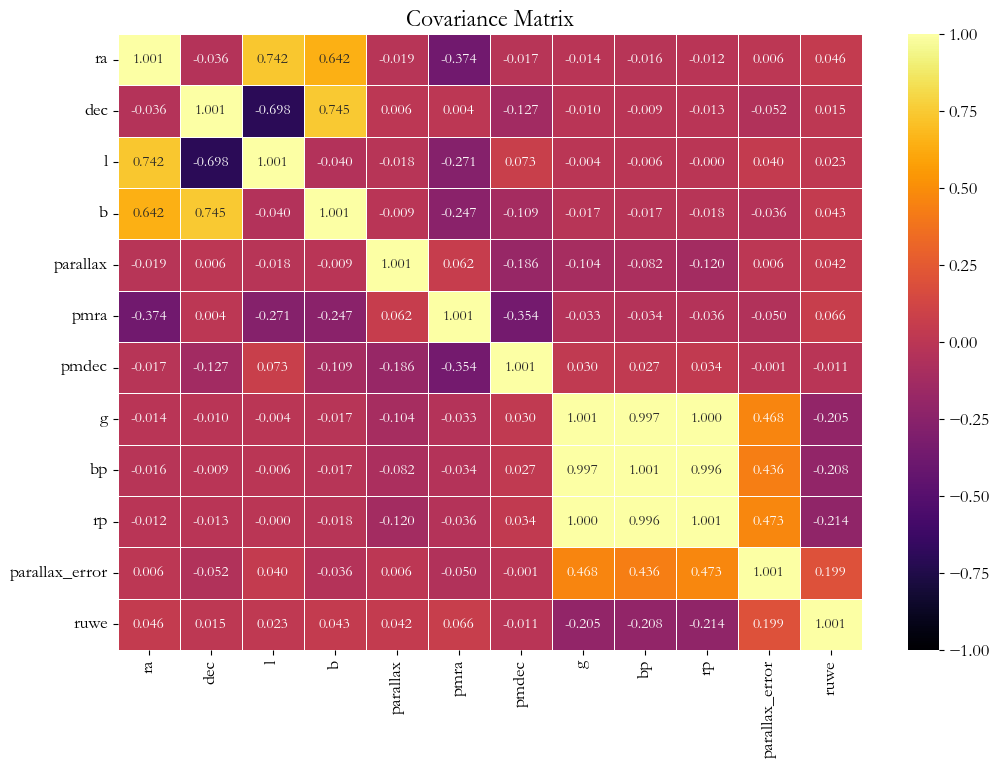

In [27]:
C = scaled_interesting_stars.cov()
plt.figure(figsize=(12, 8))

# Inserting the correlation coefficients into a heatmap in seaborn
sns.heatmap(C, annot=True, cmap='inferno', vmin=-1, vmax=1, center=0, fmt='.3f', annot_kws={"fontsize":11}, linewidths = 0.5)

# Plotting
plt.title('Covariance Matrix')
plt.show()

### The explained variance values here are the eigenvalues

[3.32844514e+00 2.23058968e+00 2.05163876e+00 1.32237517e+00
 1.14436265e+00 9.16157284e-01 5.56310651e-01 4.56581523e-01
 3.57589195e-03 9.85627261e-04 4.66365253e-05 3.18206672e-05]


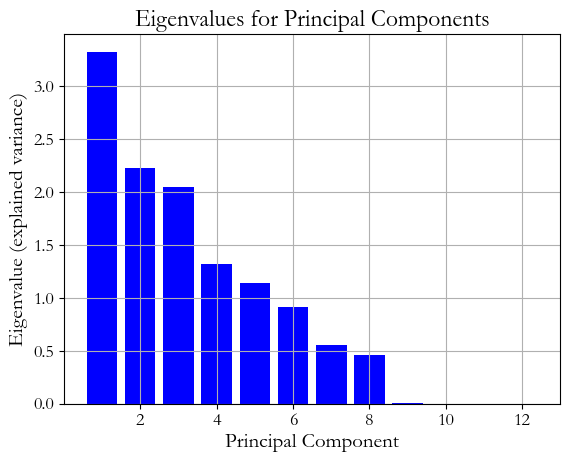

In [29]:
pca  = PCA()

pca.fit(scaled_interesting_stars)

print(pca.explained_variance_)

plt.bar(x=range(1,len(pca.explained_variance_)+1), height=pca.explained_variance_, color='b')
plt.title('Eigenvalues for Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue (explained variance)')
plt.grid(True);

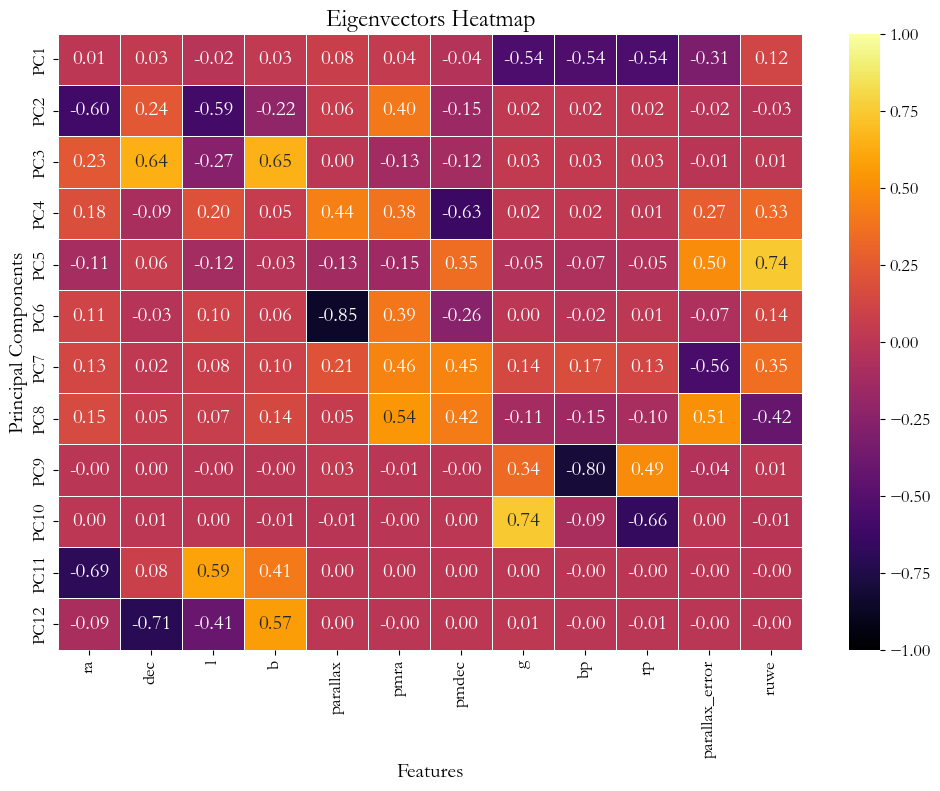

In [30]:
pca = PCA()
pca.fit(scaled_interesting_stars)

# Eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Eigenvectors (principal components)
eigenvectors = pca.components_


# Create an eigenvector dataframe
eigenvectors_df = pd.DataFrame(eigenvectors, columns=scaled_interesting_stars.columns, index=[f"PC{i+1}" for i in range(len(eigenvalues))])

# Build heatmap showing eigenvectors for each feature and each principal component
plt.figure(figsize=(12,8))
sns.heatmap(eigenvectors_df, annot=True, cmap='inferno', vmin=-1, vmax=1, center=0, fmt='.2f', linewidths=0.5)
plt.title('Eigenvectors Heatmap')
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.xticks
plt.yticks
plt.show()

### Now creating a cumulative explained variance table for each PC

In [32]:
# Create a bar chart showing the explained variance ratio per component
pca.explained_variance_ratio_
explained_variance_ratio = pca.explained_variance_ratio_

# Create a DataFrame to display the results
explained_variance_df = pd.DataFrame({
    'Principal Component': range(1, len(explained_variance_ratio) + 1),
    'Explained Variance Ratio': [f"{ratio:.2%}" for ratio in explained_variance_ratio],
    'Cumulative Explained Variance': [f"{ratio:.2%}" for ratio in explained_variance_ratio.cumsum()]})

# Do some styling
styled_table = (explained_variance_df.style
                .set_properties(**{'text-align': 'center'})
                .set_table_styles([
                    {'selector': 'th', 'props': [('background-color', '#404040'), 
                                                 ('color', 'white'),
                                                 ('font-weight', 'bold')]},
                    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f0f0f0')]},
                    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', 'white')]},
                    {'selector': 'table', 'props': [('border-collapse', 'collapse')]},
                    {'selector': 'td, th', 'props': [('border', '1px solid black'),
                                                    ('padding', '5px')]}]))

# Display the table
styled_table

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,27.71%,27.71%
1,2,18.57%,46.28%
2,3,17.08%,63.36%
3,4,11.01%,74.37%
4,5,9.53%,83.90%
5,6,7.63%,91.53%
6,7,4.63%,96.16%
7,8,3.80%,99.96%
8,9,0.03%,99.99%
9,10,0.01%,100.00%


### This explained variance ratio tells us how much of the total variance is explained by each component, expressed as a percentage


### Next up, plotting a cumulative graph for the explained variance per principal component, showing a bar chart for the individual contributions of each PC on the same y-axis as the cumulative scatter plot

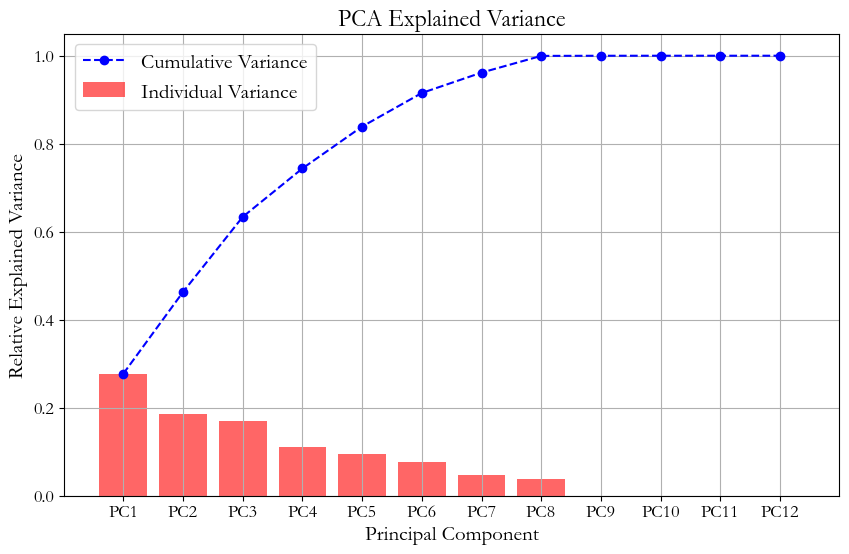

In [34]:
plt.figure(figsize=(10, 6))
plt.bar([f'PC{i+1}' for i in range(len(explained_variance_ratio))], explained_variance_ratio, alpha=0.6, label='Individual Variance', color='red')
plt.plot([f'PC{i+1}' for i in range(len(explained_variance_ratio))], np.cumsum(explained_variance_ratio), '--o', color='b', label='Cumulative Variance')
plt.xlabel('Principal Component')
plt.ylabel('Relative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

### Here we see the components of each eigenvector for PC1 and PC2

In [36]:
PC1 = pca.components_[0]
PC2 = pca.components_[1]

In [37]:
PC1

array([ 0.00693916,  0.03141588, -0.01586517,  0.02849202,  0.07666485,
        0.03970468, -0.03741121, -0.5417027 , -0.53768696, -0.54274501,
       -0.31131834,  0.12250508])

In [38]:
PC2

array([-0.59820736,  0.23879897, -0.58926409, -0.21661406,  0.05771825,
        0.40121758, -0.15458485,  0.02230938,  0.0248173 ,  0.0194926 ,
       -0.02183385, -0.0282044 ])

### Finally, displaying the eigenvalues of each PC in order alongside the percentage explained variance for each

In [40]:
# Create table data
table_data = [[f"PC{i+1}", f"{var:.4f}", f"{ratio*100:.2f}%"] for i, (var, ratio) in enumerate(zip(eigenvalues, explained_variance_ratio))]

# Define headers
headers = ["Principal Component", "Explained Variance", "Explained Variance Ratio (%)"]

# Print table
print(tabulate(table_data, headers=headers, tablefmt="grid"))

+-----------------------+----------------------+--------------------------------+
| Principal Component   |   Explained Variance | Explained Variance Ratio (%)   |
+=======================+======================+================================+
| PC1                   |               3.3284 | 27.71%                         |
+-----------------------+----------------------+--------------------------------+
| PC2                   |               2.2306 | 18.57%                         |
+-----------------------+----------------------+--------------------------------+
| PC3                   |               2.0516 | 17.08%                         |
+-----------------------+----------------------+--------------------------------+
| PC4                   |               1.3224 | 11.01%                         |
+-----------------------+----------------------+--------------------------------+
| PC5                   |               1.1444 | 9.53%                          |
+---------------

# Part 5

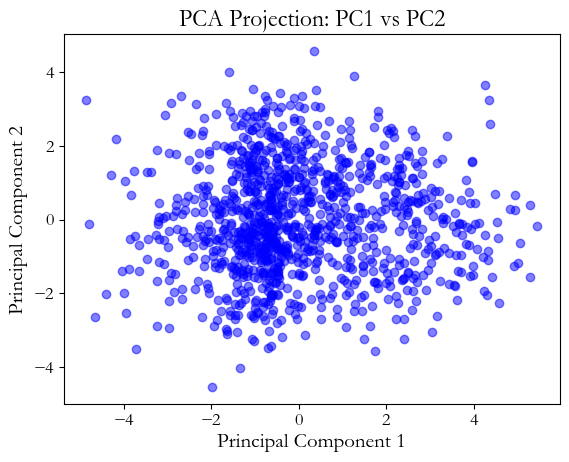

In [42]:
plt.plot(scaled_interesting_stars@PC1, scaled_interesting_stars@PC2, 'o', color='b', alpha=0.5);
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection: PC1 vs PC2');

>There is no clear trend in this scatter plot, as PC1 and PC2 both make up similar proportions of the total variance

In [44]:
# Get PCA loadings and explained variance
loadings = pd.DataFrame(
    pca.components_,
    columns=scaled_interesting_stars.columns, # Using the original dataframe's columns
    index=[f"PC-{i+1}" for i in range(pca.n_components_)])

# Add explained variance ratio to the DataFrame
loadings_with_variance = loadings.copy()
loadings_with_variance["Explained Variance"] = pca.explained_variance_ratio_

# Display top contributing features for each PC (without dropping from Series)
for pc in loadings.index:
    # Get the current PC's data (excluding "Explained Variance" column)
    pc_data = loadings.loc[pc].abs().sort_values(ascending=False)
    
    print(f"\n{pc} ({loadings_with_variance.loc[pc, 'Explained Variance']:.2%}):")
    print(pc_data.head(3))  # Show top 3 contributing features


PC-1 (27.71%):
rp    0.542745
g     0.541703
bp    0.537687
Name: PC-1, dtype: float64

PC-2 (18.57%):
ra      0.598207
l       0.589264
pmra    0.401218
Name: PC-2, dtype: float64

PC-3 (17.08%):
b      0.651861
dec    0.644561
l      0.265110
Name: PC-3, dtype: float64

PC-4 (11.01%):
pmdec       0.626357
parallax    0.444794
pmra        0.376365
Name: PC-4, dtype: float64

PC-5 (9.53%):
ruwe              0.744938
parallax_error    0.497042
pmdec             0.347489
Name: PC-5, dtype: float64

PC-6 (7.63%):
parallax    0.854256
pmra        0.392225
pmdec       0.255530
Name: PC-6, dtype: float64

PC-7 (4.63%):
parallax_error    0.560591
pmra              0.459439
pmdec             0.453912
Name: PC-7, dtype: float64

PC-8 (3.80%):
pmra              0.541772
parallax_error    0.512238
pmdec             0.418136
Name: PC-8, dtype: float64

PC-9 (0.03%):
bp    0.802545
rp    0.487908
g     0.339170
Name: PC-9, dtype: float64

PC-10 (0.01%):
g     0.744619
rp    0.661442
bp    0.088079

### Now to plot two Hertzsprung-Russel diagrams using the unscaled data - one in 2D, one in 3D

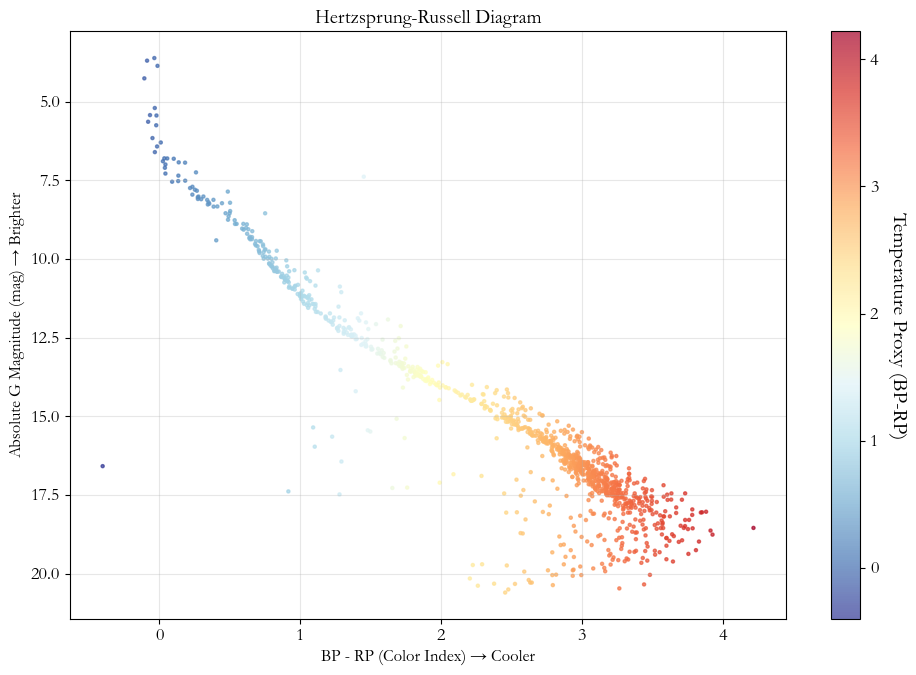

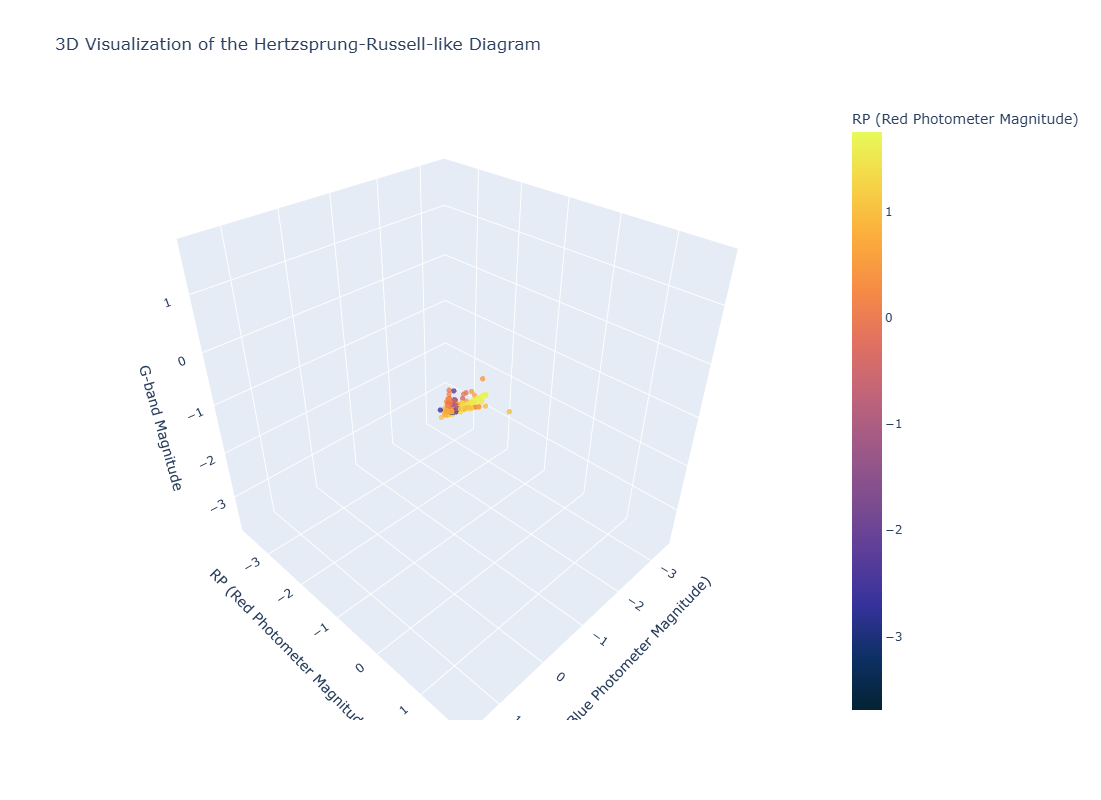

In [46]:
abscissa = unscaled_interesting_stars['bp'] - unscaled_interesting_stars['rp']
ordinate = unscaled_interesting_stars['g']

plt.figure(figsize=(10, 7))
plt.scatter(abscissa, 
            ordinate, 
            c=abscissa, 
            cmap='RdYlBu_r', 
            alpha=0.7,
            s=5)

plt.xlabel('BP - RP (Color Index) → Cooler', fontsize=12)
plt.ylabel('Absolute G Magnitude (mag) → Brighter', fontsize=12)
plt.title('Hertzsprung-Russell Diagram', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar()
cbar.set_label('Temperature Proxy (BP-RP)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

# 3D Scatter Plot
fig = px.scatter_3d(
    scaled_interesting_stars,
    x='bp',
    y='rp', 
    z='g',
    labels={
        'bp': 'BP (Blue Photometer Magnitude)',
        'rp': 'RP (Red Photometer Magnitude)',
        'g': 'G-band Magnitude'
    },
    title='3D Visualization of the Hertzsprung-Russell-like Diagram',
    color='rp',
    color_continuous_scale='thermal',
    size_max=3,
    width=1000,
    height=800
)

# Critical size adjustment
fig.update_traces(
    marker=dict(
        size=3,  # Absolute size in pixels
        sizemode='diameter',  # Use absolute sizing
        opacity=0.8,
        line=dict(width=0)  # Remove borders
    )
)